Matrix Pair 1: 3x3
Naive runtime: 0.000031 seconds
Numpy runtime: 0.000122 seconds
Same result: True

Matrix Pair 2: 6x6
Naive runtime: 0.000150 seconds
Numpy runtime: 0.000011 seconds
Same result: True

Matrix Pair 3: 12x12
Naive runtime: 0.001597 seconds
Numpy runtime: 0.000036 seconds
Same result: True

Matrix Pair 4: 24x24
Naive runtime: 0.008549 seconds
Numpy runtime: 0.000045 seconds
Same result: True

Matrix Pair 5: 48x48
Naive runtime: 0.068077 seconds
Numpy runtime: 0.000081 seconds
Same result: True

Matrix Pair 6: 96x96
Naive runtime: 0.525853 seconds
Numpy runtime: 0.000415 seconds
Same result: True

Matrix Pair 7: 192x192
Naive runtime: 4.246971 seconds
Numpy runtime: 0.000785 seconds
Same result: True

Matrix Pair 8: 384x384
Naive runtime: 34.552527 seconds
Numpy runtime: 0.004039 seconds
Same result: True



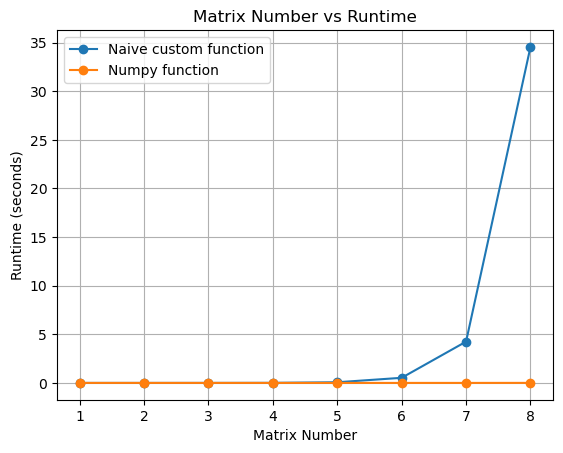

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ChatGPT was used to help organize and debug this code.

def custom_matmul(A, B):
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape

    if cols_A != rows_B:
        return None

    C = np.zeros((rows_A, cols_B))

    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                C[i, j] += A[i, k] * B[k, j]

    return C

sizes = [3]
for i in range(7):
    sizes.append(sizes[-1] * 2)

naive_times = []
numpy_times = []

for i, n in enumerate(sizes, start=1):
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)

    start = time.perf_counter()
    C1 = custom_matmul(A, B)
    end = time.perf_counter()
    naive_time = end - start
    naive_times.append(naive_time)

    start = time.perf_counter()
    C2 = np.matmul(A, B)
    end = time.perf_counter()
    numpy_time = end - start
    numpy_times.append(numpy_time)

    print(f"Matrix Pair {i}: {n}x{n}")
    print(f"Naive runtime: {naive_time:.6f} seconds")
    print(f"Numpy runtime: {numpy_time:.6f} seconds")
    print(f"Same result: {np.allclose(C1, C2)}")
    print()

plt.plot(range(1, 9), naive_times, marker='o', label='Naive custom function')
plt.plot(range(1, 9), numpy_times, marker='o', label='Numpy function')
plt.xlabel('Matrix Number')
plt.ylabel('Runtime (seconds)')
plt.title('Matrix Number vs Runtime')
plt.xticks(range(1, 9))
plt.legend()
plt.grid(True)
plt.show()